# CAMM Hackathon #10: STEM Image Restoration

STEM image credits: Austin Houston


In [ ]:
!pip install atomap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.9/868.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.8/603.8 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 105.7 MB/s eta 0:00:00


In [ ]:
!pip install pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 17.9 MB/s eta 0:00:00


In [ ]:
from pysr import PySRRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import json

In [ ]:
!gdown https://drive.google.com/file/d/14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs/view?usp=drive_link --fuzzy

Downloading...
From: https://drive.google.com/uc?id=14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs
To: /content/graphene_2.h5
100% 17.1M/17.1M [00:00<00:00, 158MB/s]


In [ ]:
!gdown https://drive.google.com/file/d/1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN/view?usp=drive_link --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN
To: /content/HAADF_21.h5
100% 4.53M/4.53M [00:00<00:00, 87.4MB/s]


In [ ]:
#@title h5 load
def save_dict_to_hdf5(file_path, data_dict):
    with h5py.File(file_path, 'w') as f:
        _recursively_save(f, data_dict)

def _recursively_save(group, data):
    if isinstance(data, dict):
        for key, value in data.items():
            subgroup = group.create_group(str(key))
            _recursively_save(subgroup, value)

    elif isinstance(data, list):
        # Turn list into group with numerical keys
        for i, item in enumerate(data):
            subgroup = group.create_group(str(i))
            _recursively_save(subgroup, item)

    elif isinstance(data, np.ndarray):
        if data.dtype == object:
            # convert each element to string (json)
            data_as_str = np.array([json.dumps(x) for x in data], dtype='S256')
            group.create_dataset('value', data=data_as_str)
        else:
            group.create_dataset('value', data=data)

    elif isinstance(data, (int, float, np.int_, np.float_)):
        group.create_dataset('value', data=data)

    elif data is None:
        group.attrs['value'] = 'None'

    else:
        # Fallback: convert unknown object to JSON string
        group.create_dataset('value', data=json.dumps(data))


def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)



def _load_item(obj):
    """
    Load any HDF5 object (Group or Dataset) and reconstruct Python object.
    """
    # ---------------------------------------------------------
    # CASE 1 — HDF5 GROUP  (recursive dict or list)
    # ---------------------------------------------------------
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())

        # Empty group → return None or empty dict
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}

        # Detect list: all keys are integers
        if all(k.isdigit() for k in keys):
            lst = []
            for k in sorted(keys, key=lambda x: int(x)):
                lst.append(_load_item(obj[k]))
            return lst

        # Regular dictionary
        out = {}
        for k in keys:
            out[k] = _load_item(obj[k])

        # Special case: group representing None
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None

        return out

    # ---------------------------------------------------------
    # CASE 2 — HDF5 DATASET  (arrays / scalars / strings)
    # ---------------------------------------------------------
    elif isinstance(obj, h5py.Dataset):
        data = obj[()]

        # Scalar
        if np.isscalar(data):
            return data

        # Byte strings → JSON or text
        if isinstance(data, (bytes, np.bytes_)):
            try:
                return json.loads(data.decode())
            except:
                return data.decode()

        # Array of byte strings
        if data.dtype.kind == "S":
            try:
                return [json.loads(x.decode()) for x in data]
            except:
                return [x.decode() for x in data]

        # Normal numpy array
        return data

    # ---------------------------------------------------------
    # CASE 3 — Attributes marking None
    # ---------------------------------------------------------
    else:
        raise ValueError("Unknown HDF5 object type:", obj)


def get_arr(runs, key):
    """
    Extract numpy array from runs[key], automatically handling nested {'value': array}.
    """
    val = runs[key]
    if isinstance(val, dict) and "value" in val:
        return np.asarray(val["value"])
    return np.asarray(val)



In [ ]:
#@title masking functions
from scipy.ndimage import binary_dilation
from skimage.draw import line as draw_line

def mask_below_line(im, row=None, frac=0.6, above=True):
    """
    Mask all pixels below (or above) a horizontal threshold row.

    Parameters
    ----------
    im : 2D array
    row   : int, absolute row index. Defaults to frac * H.
    frac  : float, fraction of height for the cut if row is None.
    above : bool, if True mask everything above the line instead.

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    H, W = im.shape
    if row is None:
        row = int(frac * H)
    mask = np.zeros((H, W), dtype=bool)
    if above:
        mask[:row, :] = True
    else:
        mask[row:, :] = True
    return mask

def mask_lakes(im, n_lakes=10, size_range=(10, 220), aspect_range=(0.5, 4.0),
               roughness=0.8, n_harmonics=34, seed=None):
    """
    Lake regions with ragged / torn borders, arranged in a loose cluster.

    The border is a polar curve whose radius is modulated by a sum of random
    sinusoids, producing irregular, non-repeating jagged edges.

    Parameters
    ----------
    im : 2D array
    n_lakes      : number of lakes
    size_range   : (min, max) semi-major axis in pixels
    aspect_range : (min, max) aspect ratio (semi-major / semi-minor)
    roughness    : 0 = smooth ellipse, 1 = very jagged (good range: 0.2–0.6)
    n_harmonics  : number of sinusoidal harmonics added to the border
    seed         : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    # loose cluster centre
    cy_c = rng.integers(H // 4, 3 * H // 4)
    cx_c = rng.integers(W // 4, 3 * W // 4)
    spread = max(H, W) // 4

    yy, xx = np.mgrid[:H, :W]

    for _ in range(n_lakes):
        cy = int(np.clip(rng.normal(cy_c, spread), 0, H - 1))
        cx = int(np.clip(rng.normal(cx_c, spread), 0, W - 1))
        a = rng.integers(*size_range)           # semi-major
        aspect = rng.uniform(*aspect_range)
        b = max(1, int(a / aspect))             # semi-minor
        angle = rng.uniform(0, np.pi)

        # rotate coordinates
        dy = yy - cy
        dx = xx - cx
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        u = cos_a * dx + sin_a * dy             # along major axis
        v = -sin_a * dx + cos_a * dy            # along minor axis

        # polar angle of every pixel relative to lake centre
        theta = np.arctan2(v, u)

        # ragged radius envelope: 1 + sum of random harmonics
        freqs = rng.integers(2, n_harmonics + 2, size=n_harmonics)
        amps  = rng.uniform(0, roughness / n_harmonics, size=n_harmonics)
        phases = rng.uniform(0, 2 * np.pi, size=n_harmonics)
        envelope = 1.0 + sum(
            amp * np.sin(freq * theta + phase)
            for amp, freq, phase in zip(amps, freqs, phases)
        )

        # pixel is inside if its normalised ellipse distance < ragged envelope
        dist = np.sqrt((u / a) ** 2 + (v / b) ** 2)
        mask |= dist <= envelope

    return ~mask

def mask_lines(im, n_lines=80, thickness=4, orientation="horizontal", seed=None):
    """
    Thin random straight lines across the image (horizontal, vertical, or diagonal).

    Parameters
    ----------
    im : 2D array
    n_lines     : number of lines
    thickness   : line width in pixels (via dilation)
    orientation : "horizontal" | "vertical" | "diagonal" | "mixed"
    seed        : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    orientations = ["horizontal", "vertical", "diagonal"]

    for _ in range(n_lines):
        if orientation == "mixed":
            ort = rng.choice(orientations)
        else:
            ort = orientation

        if ort == "horizontal":
            r = rng.integers(0, H)
            mask[r, :] = True
        elif ort == "vertical":
            c = rng.integers(0, W)
            mask[:, c] = True
        else:  # diagonal
            r0, c0 = rng.integers(0, H), rng.integers(0, W)
            r1, c1 = rng.integers(0, H), rng.integers(0, W)
            rr, cc = draw_line(r0, c0, r1, c1)
            valid = (rr >= 0) & (rr < H) & (cc >= 0) & (cc < W)
            mask[rr[valid], cc[valid]] = True

    if thickness > 1:
        struct = np.ones((thickness, thickness), dtype=bool)
        mask = binary_dilation(mask, structure=struct)

    return ~mask

def mask_small_blobs(im, n_blobs=300, size_range=(1, 24), seed=None):
    """
    Many tiny blobs simulating dead-pixel clusters or dust on the detector.

    Parameters
    ----------
    im      : 2D array
    n_blobs    : number of small blobs
    size_range : (min_r, max_r) radius in pixels
    seed       : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    yy, xx = np.ogrid[:H, :W]

    for _ in range(n_blobs):
        cy = rng.integers(0, H)
        cx = rng.integers(0, W)
        r = rng.integers(*size_range)
        mask |= (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2

    return ~mask

In [ ]:
data = load_hdf5_to_dict('/content/graphene_2.h5')
data_more = load_hdf5_to_dict('/content/HAADF_21.h5')

im0 = data['Measurement_000']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im1 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im2 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, -1000:]
im3 = data_more['Measurement_000']['Channel_000']['HAADF']['HAADF']

ims = [im0, im1, im2, im3]

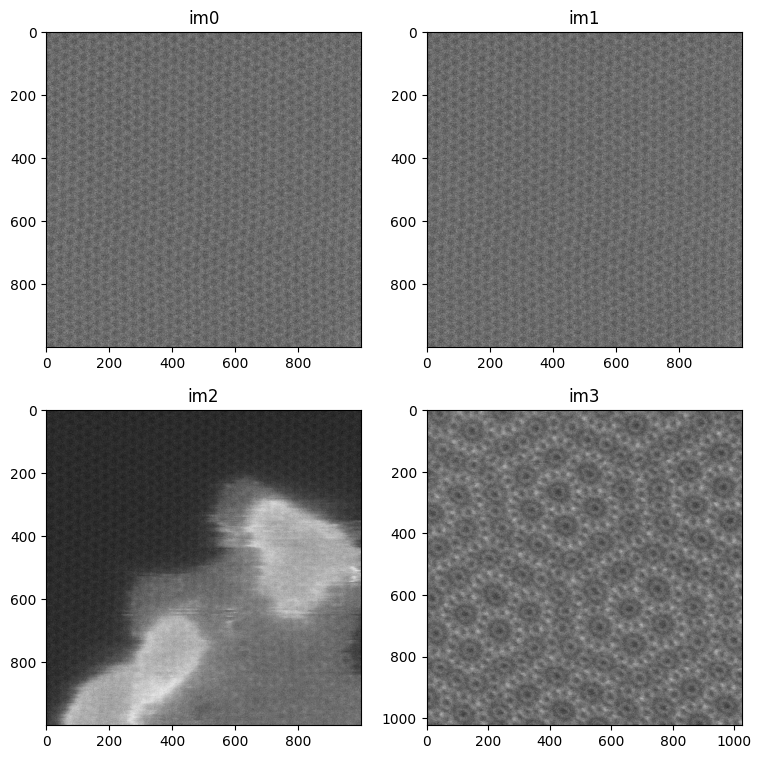

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(9,9))

ax = axes.flatten()

for i, _ in enumerate(ax):
  _.imshow(ims[i], cmap='gray')
  _.set_title(f'im{i}')

Text(0.5, 1.0, 'mask_small_blobs()')

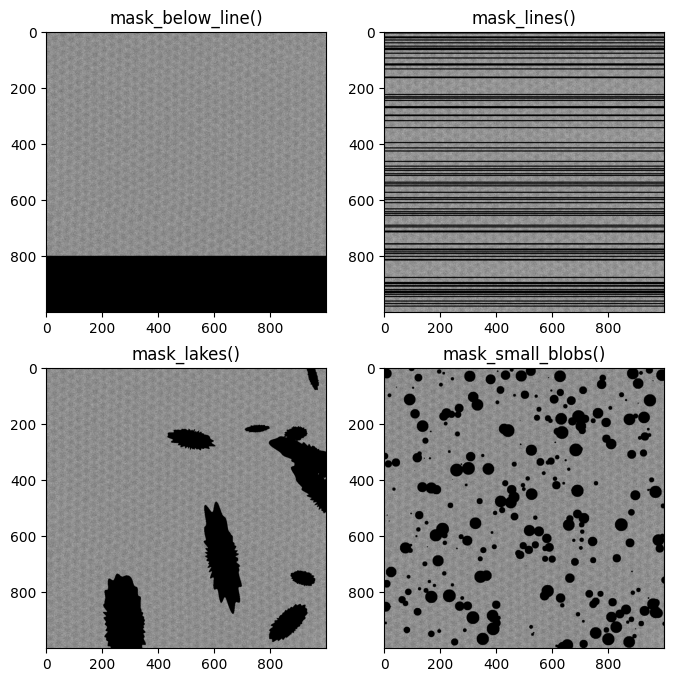

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(8,8))


ax[0,0].imshow(mask_below_line(im0, frac=0.8)*im0, cmap='gray')
ax[0,0].set_title('mask_below_line()')

ax[0,1].imshow(mask_lines(im0)*im0, cmap='gray')
ax[0,1].set_title('mask_lines()')

ax[1,0].imshow(mask_lakes(im0)*im0, cmap='gray')
ax[1,0].set_title('mask_lakes()')

ax[1,1].imshow(mask_small_blobs(im0)*im0, cmap='gray')
ax[1,1].set_title('mask_small_blobs()')


# Given a 2D microscopy intensity array and a binary loss mask, reconstruct missing regions and estimate prediction uncertainty

In [ ]:
image = mask_below_line(im3, frac=0.8)*(im3-np.min(im0))/np.ptp(im0)
mask = mask_below_line(im3, frac=0.8)

In [ ]:
import numpy as np

def sample_training_data(image, mask, strategy="combo",
                          n_total=2000, boundary_width=10, stride=5):
    """
    Returns X = (N, 2) normalised [row, col] coords
            y = (N,) pixel values
    from known pixels only (mask == 1).
    """
    H, W = image.shape

    # ── Strategy A: random uniform ──────────────────────────────
    if strategy == "random":
        rows, cols = np.where(mask == 1)
        idx = np.random.choice(len(rows),
                               min(n_total, len(rows)), replace=False)
        rows, cols = rows[idx], cols[idx]

    # ── Strategy B: grid / stride ────────────────────────────────
    elif strategy == "grid":
        r_idx = np.arange(0, H, stride)
        c_idx = np.arange(0, W, stride)
        rr, cc = np.meshgrid(r_idx, c_idx, indexing='ij')
        rr, cc = rr.ravel(), cc.ravel()
        # keep only known pixels on the grid
        valid = mask[rr, cc] == 1
        rows, cols = rr[valid], cc[valid]

    # ── Strategy C: gap-boundary strip ───────────────────────────
    elif strategy == "boundary":
        # find gap edges: columns just left/right of the gap
        gap_cols = np.where((mask == 0).any(axis=0))[0]
        left_edge  = max(0,   gap_cols.min() - boundary_width)
        right_edge = min(W-1, gap_cols.max() + boundary_width)

        # build a strip mask: known pixels within boundary_width of gap
        strip = np.zeros_like(mask)
        strip[:, left_edge  : gap_cols.min()] = 1
        strip[:, gap_cols.max()+1 : right_edge+1] = 1
        strip *= mask   # only known pixels

        rows, cols = np.where(strip == 1)

    # ── Strategy D: combo (recommended) ──────────────────────────
    elif strategy == "combo":
        # 1. grid subsample across full image
        r_idx = np.arange(0, H, stride)
        c_idx = np.arange(0, W, stride)
        rr, cc = np.meshgrid(r_idx, c_idx, indexing='ij')
        rr, cc = rr.ravel(), cc.ravel()
        valid = mask[rr, cc] == 1
        grid_rows, grid_cols = rr[valid], cc[valid]

        # 2. boundary strip — guaranteed dense near gap edges
        gap_cols_set = np.where((mask == 0).any(axis=0))[0]
        boundary_mask = np.zeros_like(mask)
        for gc in gap_cols_set:
            lo = max(0,   gc - boundary_width)
            hi = min(W-1, gc + boundary_width)
            boundary_mask[:, lo:hi+1] = 1
        boundary_mask *= mask
        b_rows, b_cols = np.where(boundary_mask == 1)

        # combine: all boundary pixels + subsample grid to fill quota
        n_boundary  = len(b_rows)
        n_remaining = max(0, n_total - n_boundary)
        if n_remaining < len(grid_rows):
            idx = np.random.choice(len(grid_rows), n_remaining, replace=False)
            grid_rows, grid_cols = grid_rows[idx], grid_cols[idx]

        rows = np.concatenate([b_rows, grid_rows])
        cols = np.concatenate([b_cols, grid_cols])

    # ── normalise coords to [0,1] ─────────────────────────────────
    X = np.stack([rows / H, cols / W], axis=1).astype(np.float32)
    y = image[rows, cols].astype(np.float32)

    print(f"  [{strategy}] {len(y)} training samples")
    return X, y

In [ ]:
def fit_symbolic_regression(X, y):
    """
    PySR searches for a compact expression f(row, col) -> value.

    Key parameters:
      niterations    : how long to evolve (more = better but slower)
      binary_operators: allowed math operations between terms
      unary_operators : allowed functions applied to single terms
      maxsize        : max complexity of the expression tree
      populations    : diversity of the search (more = better search)

    For step images we include sin/cos since the structure is sinusoidal.
    PySR will find something like: 0.4*sin(6.28*x1) + 0.2*sin(...) + 0.5
    """
    model = PySRRegressor(
        niterations      = 50,           # generations of evolution
        binary_operators = ["+", "-", "*"],
        unary_operators  = ["sin", "cos"],
        maxsize          = 20,           # max nodes in expression tree
        populations      = 15,           # parallel populations
        population_size  = 50,
        verbosity        = 1,
        # select the simplest expression within 1% of best MSE
        model_selection  = "best",
        warm_start=True,
        batching         = True,  # ← add this
        batch_size       = 7000,   #← and this
        complexity_of_operators={"sin": 1, "cos": 1},
        nested_constraints={
        "sin": {"sin": 0, "cos": 0},
        "cos": {"sin": 0, "cos": 0},}
    )

    print("\nFitting symbolic regression (this takes ~1-2 min for 50 iters) ...")
    model.fit(X, y)

    print(f"\nBest expression found:")
    print(f"  {model.sympy()}")
    print(f"  complexity : {model.get_best()['complexity']}")
    print(f"  train MSE  : {model.get_best()['loss']:.6f}")

    return model

In [ ]:
X, r = sample_training_data(image, mask, strategy='grid', stride=3)

  [grid] 93366 training samples


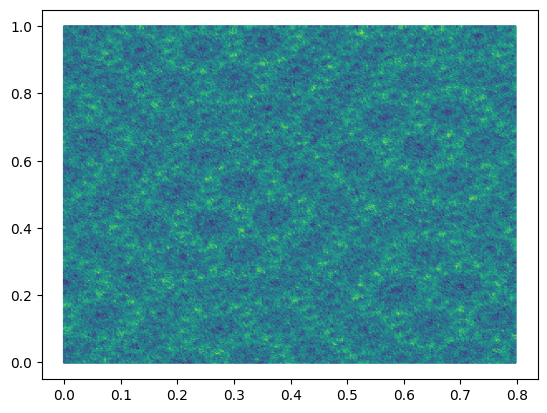

In [ ]:
plt.scatter(*X.T, s=1, c=r)

In [ ]:
model = fit_symbolic_regression(X, r)


Fitting symbolic regression (this takes ~1-2 min for 50 iters) ...


/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.060e+01
Progress: 4 / 750 total iterations (0.533%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.494e-04  0.000e+00  y = 0.2501
5           8.494e-04  8.345e-07  y = (x₀ - x₀) - -0.25029
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 4.550e+02
Progress: 26 / 750 total iterations (3.467%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss   

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.494e-04  0.000e+00  y = 0.2502
5           8.492e-04  6.668e-05  y = (x₁ * -0.001538) + 0.25097
6           8.491e-04  3.660e-05  y = 0.25101 - (sin(x₁) * 0.0018064)
7           8.490e-04  1.652e-04  y = ((x₁ - x₀) * -0.0019365) + 0.2505
8           8.490e-04  2.205e-05  y = 0.2505 + (-0.0019365 * (sin(x₁) - x₀))
9           8.486e-04  4.217e-04  y = (((0.65493 - x₀) * x₁) * -0.0056767) + 0.25096
10          8.484e-04  2.940e-04  y = (x₁ * (cos(x₀ + x₁) * -0.0066891)) + 0.25162
13          8.483e-04  3.418e-05  y = ((1.0062 - cos(x₁)) * (cos(x₀ + x₁) * -0.019048)) + 0....
                                      25152
15          8.483e-04  4.113e-06  y = (((1.0062 - (cos(x₁) * 0.99461)) * -0.019048) * cos(x₁...
                                       + x₀)) + 0.25152
18          8.482e-04  2.082e-05  y = (cos(x₁ + x₀) * ((1.0062 - (co

In [ ]:
def predict_gap(model, mask, idx = None):
    """
    Evaluate the discovered equation at every gap pixel coordinate.
    Returns
        recon     : same shape as mask, known pixels untouched
        gap_rows  : row indices of gap pixels
        gap_cols  : col indices of gap pixels
        gap_preds : predicted values at those pixels
    """
    H, W = mask.shape
    gap_rows, gap_cols = np.where(mask == 0)

    X_gap = np.stack([gap_rows / H,
                      gap_cols / W], axis=1).astype(np.float32)

    if idx is not None:
      gap_preds = model.predict(X_gap, index=idx)
    else:
      gap_preds = model.predict(X_gap)
    gap_preds = np.clip(gap_preds, 0, 1).astype(np.float32)

    return gap_preds, gap_rows, gap_cols

In [ ]:
model

PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                          0.2502014   
	1        0.000067                    (x1 * -0.00153801) + 0.25097236   
	2        0.000037              0.25100747 - (sin(x1) * 0.0018064195)   
	3        0.000165             ((x1 - x0) * -0.001936452) + 0.2504981   
	4        0.000022        0.2504981 + (-0.001936452 * (sin(x1) - x0))   
	5  >>>>  0.000422  (((0.6549254 - x0) * x1) * -0.005676666) + 0.2...   
	6        0.000294  (x1 * (cos(x0 + x1) * -0.006689109)) + 0.25161538   
	7        0.000034  ((1.006175 - cos(x1)) * (cos(x0 + x1) * -0.019...   
	8        0.000004  (((1.006175 - (cos(x1) * 0.9946065)) * -0.0190...   
	9        0.000021  (cos(x1 + x0) * ((1.006175 - (cos(x1) * cos(x0...   
	
	       loss  complexity  
	0  0.000849           1  
	1  0.000849           5  
	2  0.000849           6  
	3  0.000849           7  
	4  0.000849           8  
	5  0.000849           9  
	6  0.000848          10  
	7  0.000848          13  
	8  0.000848          15  
	9  0.000848          18  
]

In [ ]:
gap_preds, gap_rows, gap_cols = predict_gap(model, mask)

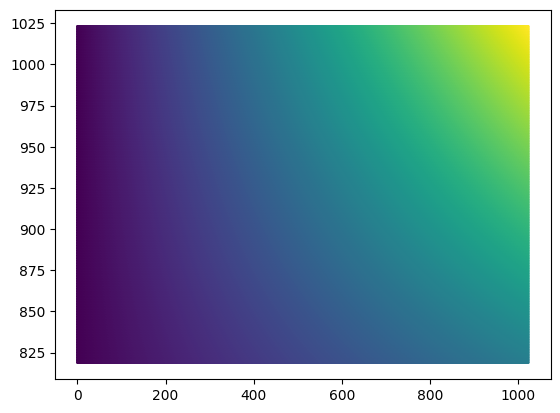

In [ ]:
plt.scatter(gap_cols, gap_rows, c=gap_preds, s=1)


In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter
from PIL import Image
import matplotlib.pyplot as plt
import sys
import os


# ─────────────────────────────────────────────────────────────────
# 1. I/O
# ─────────────────────────────────────────────────────────────────

def load(image_path: str, mask_path: str):
    """
    Load grayscale image and binary mask.
    Mask: white (255) = known, black (0) = gap.
    Returns float32 arrays in [0, 1].
    """
    img  = Image.open(image_path).convert("L")
    msk  = Image.open(mask_path).convert("L")

    # resize mask to match image if needed
    if img.size != msk.size:
        msk = msk.resize(img.size, Image.NEAREST)

    image = np.array(img, dtype=np.float32) / 255.0
    mask  = (np.array(msk, dtype=np.float32) > 127).astype(np.float32)
    return image, mask


def make_synthetic(H=256, W=256):
    """
    Synthetic test: sinusoidal step image + rectangular gap.
    Use this when you don't have real files yet.
    """
    x  = np.linspace(0, 6 * np.pi, W)
    y  = np.linspace(0, 2 * np.pi, H)
    XX, YY = np.meshgrid(x, y)
    image = (
        0.40 * np.sin(XX)
      + 0.20 * np.sin(2 * XX)
      + 0.15 * np.sin(XX + YY)
      + 0.10 * np.cos(3 * XX)
      + 0.50
    ).astype(np.float32)
    image = np.clip(image, 0, 1)

    mask = np.ones((H, W), dtype=np.float32)
    mask[:, 60:100]  = 0   # interior gap
    mask[:, 200:260] = 0   # wider gap
    mask[:, 230:]    = 0   # edge gap (hard for GP, fine here)
    return image, mask


# ─────────────────────────────────────────────────────────────────
# 2. Learn spectral kernel from known pixels
# ─────────────────────────────────────────────────────────────────

def learn_spectrum(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    Estimate the true power spectral density from the known pixels.

    Naive approach: FFT the masked image → spectrum is biased because
    the zeros in the gap distort all frequencies.

    Correction (Wiener-style):
      The observed spectrum = true spectrum × (fraction of known pixels
      per spatial frequency).  We estimate that fraction from the mask's
      own FFT, then divide it out.

    Returns:
        psd_smooth : (H, W) real-valued estimated power spectrum,
                     smoothed slightly so noisy frequency bins don't
                     destabilise the inpainting loop.
    """
    H, W = image.shape

    # fill gap with mean before FFT to avoid hard-edge ringing
    mean_val   = image[mask == 1].mean()
    img_filled = image.copy()
    img_filled[mask == 0] = mean_val

    # FFT of the mean-filled image
    F_obs = np.fft.fft2(img_filled)
    P_obs = np.abs(F_obs) ** 2              # observed power spectrum

    # FFT of the mask — tells us how each frequency was "covered"
    F_mask   = np.fft.fft2(mask)
    P_mask   = np.abs(F_mask) ** 2
    coverage = P_mask / (H * W)             # normalise to [0, 1] roughly

    # Wiener correction: divide out the mask's spectral footprint
    # clip denominator to avoid division by near-zero
    coverage_safe = np.maximum(coverage, 1e-3)
    psd_corrected = P_obs / coverage_safe

    # smooth the estimated PSD so isolated noisy bins don't dominate
    # sigma=1 is gentle — just removes single-pixel spikes in freq domain
    psd_smooth = gaussian_filter(psd_corrected, sigma=1.0)

    # normalise so the amplitude envelope has unit mean
    psd_smooth = psd_smooth / (psd_smooth.mean() + 1e-10)

    return psd_smooth.astype(np.float32)


# ─────────────────────────────────────────────────────────────────
# 3. Nearest-neighbour initialisation
# ─────────────────────────────────────────────────────────────────

def nn_init(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    Fill each gap pixel with the nearest known pixel along its row.
    Much better than mean-fill: FFT sees a smooth signal from iter 0
    so convergence is real from the first iteration.
    """
    filled = image.copy()
    H, W   = image.shape
    global_mean = image[mask == 1].mean()

    for r in range(H):
        row_mask = mask[r]
        if row_mask.all():          # no gap
            continue
        known_idx = np.where(row_mask == 1)[0]
        if len(known_idx) == 0:     # entire row missing
            filled[r, :] = global_mean
            continue
        gap_idx = np.where(row_mask == 0)[0]
        # vectorised nearest-neighbour lookup
        dists   = np.abs(gap_idx[:, None] - known_idx[None, :])
        nearest = known_idx[dists.argmin(axis=1)]
        filled[r, gap_idx] = image[r, nearest]

    return filled


# ─────────────────────────────────────────────────────────────────
# 4. Core inpainting loop
# ─────────────────────────────────────────────────────────────────

def inpaint(image: np.ndarray,
            mask:  np.ndarray,
            n_iter: int = 300,
            tol:    float = 1e-7) -> tuple:
    """
    Iterative spectral inpainting guided by the learned power spectrum.

    Each iteration alternates two projections:

      Spectral projection:
        FFT the current estimate → scale each frequency bin so that
        the amplitude envelope matches the learned PSD → IFFT back.
        This forces the reconstruction to have the same spectral
        character as the known region.

      Spatial projection:
        Known pixels are snapped back to their original values.
        Gap pixels keep the spectrally-projected values.

    Args:
        image   : (H, W) float32 in [0, 1]
        mask    : (H, W) float32 — 1=known, 0=gap
        n_iter  : maximum iterations
        tol     : convergence threshold on gap pixel change

    Returns:
        recon       : (H, W) reconstructed image
        uncertainty : (H, W) per-pixel uncertainty estimate
        history     : list of gap-change values per iteration
    """
    H, W = image.shape
    print(f"  Image  : {H}×{W}")
    print(f"  Known  : {int(mask.sum())} px  ({100*mask.mean():.1f}%)")
    print(f"  Gap    : {int((mask==0).sum())} px  ({100*(1-mask.mean()):.1f}%)")

    # ── step 1: learn spectral kernel from known pixels ──────────
    print("  Learning spectral kernel ...", end=" ", flush=True)
    psd = learn_spectrum(image, mask)
    print("done")

    # ── step 2: initialise gap pixels ────────────────────────────
    current = nn_init(image, mask)

    # ── step 3: iterate ──────────────────────────────────────────
    history     = []
    # track a rolling window of gap values to estimate uncertainty
    gap_mask    = mask == 0
    snapshots   = []

    print(f"  Iterating (max {n_iter}) ...")
    for i in range(n_iter):
        prev_gap = current[gap_mask].copy()

        # ── spectral projection ──────────────────────────────────
        F = np.fft.fft2(current)

        # annealed spectral gate:
        # early iters: soft gate (preserves low freqs, gently damps high)
        # late iters : hard gate (strongly enforces learned spectrum shape)
        # psd >> 1 at dominant frequencies → gate → 1 (pass through)
        # psd ~  0 at absent frequencies  → gate → 0 (suppress)
        sharpness = 1.0 + 8.0 * (i / n_iter)    # 1 → 9 over iterations
        gate      = psd ** sharpness / (psd ** sharpness + 1.0)
        F_new     = F * gate

        candidate = np.real(np.fft.ifft2(F_new))

        # ── spatial projection ───────────────────────────────────
        current = mask * image + (1 - mask) * candidate

        # ── convergence check ────────────────────────────────────
        gap_change = float(np.abs(current[gap_mask] - prev_gap).mean())
        history.append(gap_change)

        if (i + 1) % 50 == 0 or i == 0:
            print(f"    iter {i+1:4d}  gap Δ = {gap_change:.2e}")

        # collect snapshots for uncertainty estimate (last 20 iters)
        if i >= n_iter - 20:
            snapshots.append(current[gap_mask].copy())

        if gap_change < tol and i > 10:
            print(f"    converged at iter {i+1}")
            break

    # ── step 4: uncertainty = std across last 20 iterations ──────
    uncertainty = np.zeros_like(image)
    if len(snapshots) > 1:
        snap_arr = np.stack(snapshots, axis=0)           # (T, N_gap)
        uncertainty[gap_mask] = snap_arr.std(axis=0)

    recon = np.clip(current, 0, 1).astype(np.float32)
    return recon, uncertainty.astype(np.float32), history


# ─────────────────────────────────────────────────────────────────
# 5. Metrics
# ─────────────────────────────────────────────────────────────────

def metrics(original, recon, mask):
    gap  = mask == 0
    diff = original[gap] - recon[gap]
    mse  = float(np.mean(diff ** 2))
    mae  = float(np.mean(np.abs(diff)))
    psnr = float(10 * np.log10(1.0 / mse)) if mse > 1e-12 else float("inf")
    print(f"\n  Gap metrics — MSE {mse:.5f}  MAE {mae:.5f}  PSNR {psnr:.1f} dB")
    return mse, mae, psnr


# ─────────────────────────────────────────────────────────────────
# 6. Visualise
# ─────────────────────────────────────────────────────────────────

def visualise(image, mask, recon, uncertainty, history, out_path="result.png"):
    masked = image.copy()
    masked[mask == 0] = 0.5

    err = np.abs(image - recon)
    err[mask == 1] = 0          # only show gap error

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    panels = [
        (image,       "Original",                "gray",  0, 1),
        (masked,      "Masked input",            "gray",  0, 1),
        (recon,       "Reconstructed",           "gray",  0, 1),
        (err,         "Error (gap only)",        "hot",   0, 0.1),
        (uncertainty, "Uncertainty (std)",       "plasma",None,None),
    ]
    for ax, (img, title, cmap, vmin, vmax) in zip(axes.flat, panels):
        kw = {"cmap": cmap}
        if vmin is not None:
            kw["vmin"] = vmin
            kw["vmax"] = vmax
        im = ax.imshow(img, **kw)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # convergence curve
    ax = axes.flat[5]
    ax.semilogy(history, color="steelblue", lw=1.5)
    ax.set_title("Convergence", fontsize=11)
    ax.set_xlabel("iteration")
    ax.set_ylabel("gap Δ (log)")
    ax.grid(True, alpha=0.3)

    # profile through middle row
    mid = image.shape[0] // 2
    fig2, ax2 = plt.subplots(figsize=(10, 3))
    ax2.plot(image[mid],  color="black",      lw=2,   label="original",  alpha=0.8)
    ax2.plot(recon[mid],  color="steelblue",  lw=1.5, label="recon",     ls="--")
    ax2.fill_between(
        np.arange(image.shape[1]),
        recon[mid] - uncertainty[mid],
        recon[mid] + uncertainty[mid],
        alpha=0.25, color="steelblue", label="±1 std"
    )
    # shade gap columns
    changes = np.diff((mask[mid] == 0).astype(int), prepend=0, append=0)
    for s, e in zip(np.where(changes == 1)[0], np.where(changes == -1)[0]):
        ax2.axvspan(s, e, alpha=0.12, color="red")
    ax2.set_title("Row profile — middle row  (red = gap)")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    fig2.tight_layout()
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    profile_path = out_path.replace(".png", "_profile.png")
    fig2.savefig(profile_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\n  Saved → {out_path}")
    print(f"  Saved → {profile_path}")


In [ ]:
recon, uncertainty, history = inpaint(image, mask, n_iter=2000)

  Image  : 1024×1024
  Known  : 838656 px  (80.0%)
  Gap    : 209920 px  (20.0%)
  Learning spectral kernel ... done
  Iterating (max 2000) ...
    iter    1  gap Δ = 2.95e-03
    iter   50  gap Δ = 1.73e-04
    iter  100  gap Δ = 1.54e-04
    iter  150  gap Δ = 9.42e-05
    iter  200  gap Δ = 5.53e-05
    iter  250  gap Δ = 3.23e-05
    iter  300  gap Δ = 1.94e-05
    iter  350  gap Δ = 1.26e-05
    iter  400  gap Δ = 9.22e-06
    iter  450  gap Δ = 7.55e-06
    iter  500  gap Δ = 6.71e-06
    iter  550  gap Δ = 6.25e-06
    iter  600  gap Δ = 5.95e-06
    iter  650  gap Δ = 5.75e-06
    iter  700  gap Δ = 5.58e-06
    iter  750  gap Δ = 5.45e-06
    iter  800  gap Δ = 5.33e-06
    iter  850  gap Δ = 5.23e-06
    iter  900  gap Δ = 5.13e-06
    iter  950  gap Δ = 5.05e-06
    iter 1000  gap Δ = 4.97e-06
    iter 1050  gap Δ = 4.90e-06
    iter 1100  gap Δ = 4.84e-06
    iter 1150  gap Δ = 4.78e-06
    iter 1200  gap Δ = 4.72e-06
    iter 1250  gap Δ = 4.67e-06
    iter 1300  gap Δ = 4

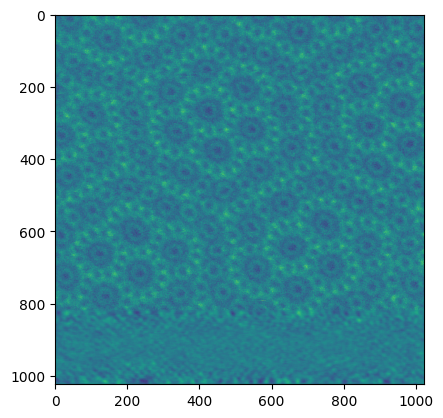

In [ ]:
plt.imshow(recon)

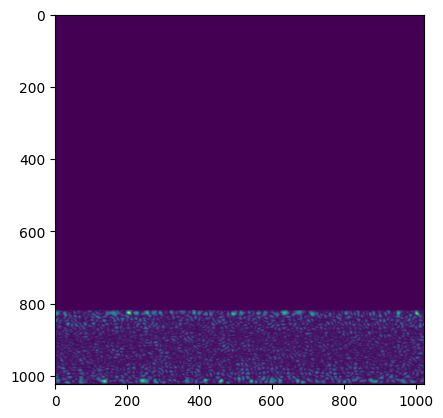

In [ ]:
plt.imshow(uncertainty)

In [ ]:
image = mask_lakes(im3)*(im3-np.min(im0))/np.ptp(im0)
mask = mask_lakes(im3)

In [ ]:
recon1, uncertainty1, history = inpaint(image, mask, n_iter=2000)

  Image  : 1024×1024
  Known  : 847747 px  (80.8%)
  Gap    : 200829 px  (19.2%)
  Learning spectral kernel ... done
  Iterating (max 2000) ...
    iter    1  gap Δ = 1.67e-01
    iter   50  gap Δ = 9.83e-05
    iter  100  gap Δ = 8.70e-05
    iter  150  gap Δ = 7.84e-05
    iter  200  gap Δ = 7.17e-05
    iter  250  gap Δ = 6.64e-05
    iter  300  gap Δ = 6.20e-05
    iter  350  gap Δ = 5.82e-05
    iter  400  gap Δ = 5.48e-05
    iter  450  gap Δ = 5.16e-05
    iter  500  gap Δ = 4.86e-05
    iter  550  gap Δ = 4.58e-05
    iter  600  gap Δ = 4.32e-05
    iter  650  gap Δ = 4.07e-05
    iter  700  gap Δ = 3.83e-05
    iter  750  gap Δ = 3.61e-05
    iter  800  gap Δ = 3.41e-05
    iter  850  gap Δ = 3.22e-05
    iter  900  gap Δ = 3.04e-05
    iter  950  gap Δ = 2.88e-05
    iter 1000  gap Δ = 2.73e-05
    iter 1050  gap Δ = 2.60e-05
    iter 1100  gap Δ = 2.47e-05
    iter 1150  gap Δ = 2.35e-05
    iter 1200  gap Δ = 2.24e-05
    iter 1250  gap Δ = 2.14e-05
    iter 1300  gap Δ = 2

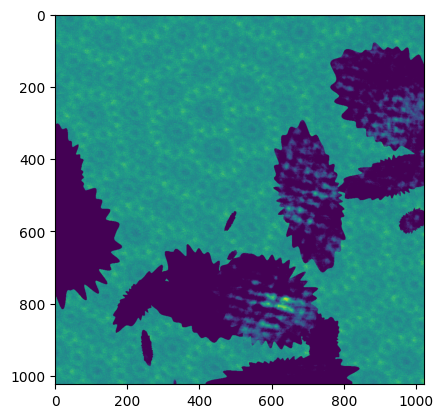

In [ ]:
plt.imshow(recon1)

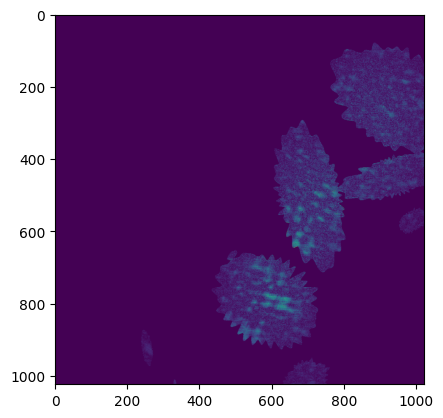

In [ ]:
plt.imshow(uncertainty1)

In [ ]:
def spectral_inpaint(image, mask, n_iter=200, verbose=True):
    """
    Iterative spectral inpainting (Gerchberg-Papoulis algorithm).

    The loop alternates between two constraints:
      - Spatial constraint:  known pixels must match the original image
      - Spectral constraint: spectrum must be consistent with what we learned
                             from the known pixels

    Args:
        image  : (H, W) float32 in [0, 1]
        mask   : (H, W) float32 — 1=known, 0=gap
        n_iter : number of iterations (100-500 is usually enough)

    Returns:
        recon  : (H, W) reconstructed image
        history: list of residuals per iteration (for convergence plot)
    """
    H, W = image.shape

    # ── estimate the target power spectrum from known pixels only ──
    # We can't just FFT the masked image — the zeros in the gap
    # would distort all frequencies.
    # Instead: normalize by the fraction of known pixels per frequency,
    # using the Wiener-style estimate on the visible region.

    # first pass: fill gap with the image mean so FFT doesn't see hard edges
    mean_val = image[mask == 1].mean()
    current  = image.copy()
    current[mask == 0] = mean_val    # initial guess for gap pixels

    # estimate reference spectrum amplitude from the known-pixel region
    # We use the current (mean-filled) image as a first estimate
    ref_spectrum = np.fft.fft2(current)     # shape (H, W), complex

    history = []

    for i in range(n_iter):
        prev = current.copy()

        # ── SPECTRAL STEP ──
        # FFT the current estimate
        spectrum = np.fft.fft2(current)

        # Replace amplitudes with reference amplitudes, keep phases
        # This is the key: we trust the frequency content we estimated
        # from the known pixels, but let the phases adapt.
        amplitude_ref  = np.abs(ref_spectrum)
        amplitude_cur  = np.abs(spectrum)

        # avoid division by zero at DC or zero-amplitude frequencies
        safe_amp = np.where(amplitude_cur > 1e-10,
                            amplitude_cur, 1e-10)

        # rescale spectrum to match reference amplitudes
        spectrum_corrected = spectrum * (amplitude_ref / safe_amp)

        # IFFT back to spatial domain
        candidate = np.real(np.fft.ifft2(spectrum_corrected))

        # ── SPATIAL STEP ──
        # Known pixels snap back to ground truth.
        # Gap pixels take the candidate value.
        current = mask * image + (1 - mask) * candidate

        # track convergence: how much did the gap pixels change?
        gap_change = np.abs(current - prev)[mask == 0].mean()
        history.append(gap_change)

        if verbose and (i % 50 == 0 or i == n_iter - 1):
            print(f"  iter {i:4d}  gap change: {gap_change:.6f}")

        # early stopping if converged
        if gap_change < 1e-7:
            print(f"  converged at iter {i}")
            break

    return np.clip(current, 0, 1).astype(np.float32), history


In [ ]:
print("Running global spectral inpainting ...")
recon_global, history = spectral_inpaint(image, mask, n_iter=300)
    # print("\nGlobal result:")
    # evaluate(image, recon_global, mask)

Running global spectral inpainting ...
  iter    0  gap change: 0.000000
  converged at iter 0


In [ ]:
import matplotlib.patches as mpatches
from scipy.ndimage import binary_dilation
mask = mask_below_line(im0, frac=0.8)
image = (im0 - im0.min())/np.ptp(im0)*mask

Image          : 1000 × 1000
Observed       : 800000 px  (80.0%)
Missing bbox   : rows 800–999, cols 0–999
Missing size   : 200 × 1000 px
Boundary strip : 1000 px


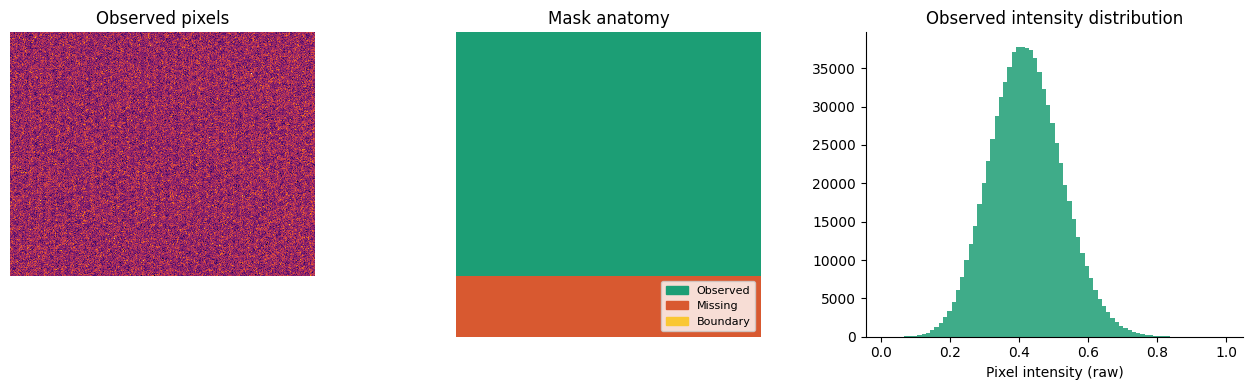

In [ ]:
H, W  = image.shape

# ── 1b. Normalise to [0, 1] ─────────────────────────────────
obs       = image[mask]
img_min   = obs.min()
img_max   = obs.max()
scale     = img_max - img_min if img_max > img_min else 1.0
img_norm  = (image - img_min) / scale   # work in [0,1] throughout

# ── 1c. Characterise the missing region ─────────────────────
rows_miss, cols_miss = np.where(~mask)
miss_rmin, miss_rmax = rows_miss.min(), rows_miss.max()
miss_cmin, miss_cmax = cols_miss.min(), cols_miss.max()
miss_h = miss_rmax - miss_rmin + 1
miss_w = miss_cmax - miss_cmin + 1

boundary = binary_dilation(~mask, iterations=1) & mask

print(f"Image          : {H} × {W}")
print(f"Observed       : {mask.sum()} px  ({100*mask.mean():.1f}%)")
print(f"Missing bbox   : rows {miss_rmin}–{miss_rmax}, cols {miss_cmin}–{miss_cmax}")
print(f"Missing size   : {miss_h} × {miss_w} px")
print(f"Boundary strip : {boundary.sum()} px")

# ── 1d. Visualise ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(np.where(mask, img_norm, np.nan),
               cmap="inferno", interpolation="nearest", vmin=0, vmax=1)
axes[0].set_title("Observed pixels")
axes[0].axis("off")

overlay = np.zeros((H, W, 3))
overlay[mask]     = [0.11, 0.62, 0.46]   # teal  — observed
overlay[~mask]    = [0.85, 0.35, 0.19]   # coral — missing
overlay[boundary] = [0.98, 0.78, 0.20]   # amber — boundary
axes[1].imshow(overlay, interpolation="nearest")
axes[1].legend(handles=[
    mpatches.Patch(color=(0.11,0.62,0.46), label="Observed"),
    mpatches.Patch(color=(0.85,0.35,0.19), label="Missing"),
    mpatches.Patch(color=(0.98,0.78,0.20), label="Boundary"),
], fontsize=8, loc="lower right")
axes[1].set_title("Mask anatomy")
axes[1].axis("off")

axes[2].hist(obs, bins=80, color="#1D9E75", edgecolor="none", alpha=0.85)
axes[2].set_xlabel("Pixel intensity (raw)")
axes[2].set_title("Observed intensity distribution")
axes[2].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ── 2a. Feed only the observed region into atomap ───────────

# Diagnose first — see what coverage actually looks like
row_coverage = mask.mean(axis=1)   # fraction observed per row
col_coverage = mask.mean(axis=0)   # fraction observed per col

print(f"Row coverage — min: {row_coverage.min():.2f}  "
      f"max: {row_coverage.max():.2f}  "
      f"mean: {row_coverage.mean():.2f}")
print(f"Col coverage — min: {col_coverage.min():.2f}  "
      f"max: {col_coverage.max():.2f}  "
      f"mean: {col_coverage.mean():.2f}")

# Use a threshold just below your actual minimum coverage
# (0.8 was too strict — lower it to match your data)
row_thresh = row_coverage.max() * 0.5   # 50% of the best row
col_thresh = col_coverage.max() * 0.5

obs_rows = np.where(row_coverage > row_thresh)[0]
obs_cols = np.where(col_coverage > col_thresh)[0]

print(f"\nWith adaptive threshold:")
print(f"  obs_rows : {len(obs_rows)} rows  "
      f"({obs_rows[0]}–{obs_rows[-1]})")
print(f"  obs_cols : {len(obs_cols)} cols  "
      f"({obs_cols[0]}–{obs_cols[-1]})")

crop = img_norm[obs_rows[0]:obs_rows[-1]+1,
                obs_cols[0]:obs_cols[-1]+1]

# Zero-fill any residual missing pixels inside the crop
# (atomap dislikes NaN or blank patches)
crop_mask = mask[obs_rows[0]:obs_rows[-1]+1,
                 obs_cols[0]:obs_cols[-1]+1]
crop_mean = crop[crop_mask].mean()
crop      = np.where(crop_mask, crop, crop_mean)

print(f"\nCrop shape : {crop.shape}")
print(f"Crop range : [{crop.min():.3f}, {crop.max():.3f}]")

Row coverage — min: 0.00  max: 1.00  mean: 0.80
Col coverage — min: 0.80  max: 0.80  mean: 0.80

With adaptive threshold:
  obs_rows : 800 rows  (0–799)
  obs_cols : 1000 cols  (0–999)

Crop shape : (800, 1000)
Crop range : [0.000, 1.000]


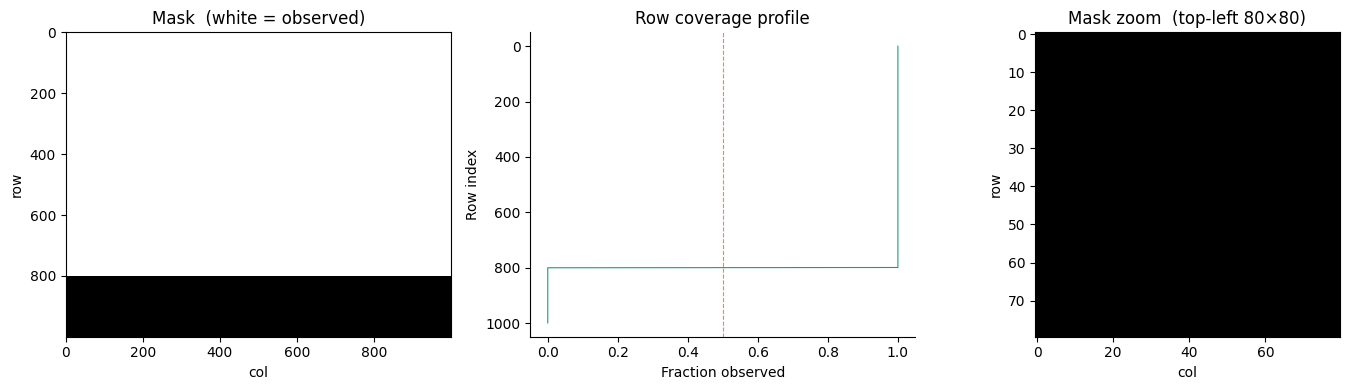

Fully observed rows : 800
Fully missing rows  : 200
Partial rows        : 0

Observed row spacing — unique gaps: [1]
  → every 1 rows, 0 are missing

First 10 missing rows  : [800 801 802 803 804 805 806 807 808 809]
First 10 observed rows : [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# ── Diagnose the exact mask structure ──────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. The mask itself
axes[0].imshow(mask, cmap="gray", interpolation="nearest", aspect="auto")
axes[0].set_title("Mask  (white = observed)")
axes[0].set_xlabel("col")
axes[0].set_ylabel("row")

# 2. Row coverage profile
axes[1].plot(mask.mean(axis=1), np.arange(H), lw=0.8, color="#1D9E75")
axes[1].set_xlabel("Fraction observed")
axes[1].set_ylabel("Row index")
axes[1].set_title("Row coverage profile")
axes[1].invert_yaxis()
axes[1].axvline(0.5, color="coral", lw=0.8, linestyle="--")
axes[1].spines[["top","right"]].set_visible(False)

# 3. Zoom into a small patch to see the pattern
axes[2].imshow(mask[:80, :80], cmap="gray", interpolation="nearest")
axes[2].set_title("Mask zoom  (top-left 80×80)")
axes[2].set_xlabel("col")
axes[2].set_ylabel("row")

plt.tight_layout()
plt.show()

# ── Print the row pattern precisely ────────────────────────
row_coverage = mask.mean(axis=1)
observed_rows = np.where(row_coverage == 1.0)[0]
missing_rows  = np.where(row_coverage == 0.0)[0]
partial_rows  = np.where((row_coverage > 0) & (row_coverage < 1))[0]

print(f"Fully observed rows : {len(observed_rows)}")
print(f"Fully missing rows  : {len(missing_rows)}")
print(f"Partial rows        : {len(partial_rows)}")

if len(observed_rows) > 1:
    gaps = np.diff(observed_rows)
    print(f"\nObserved row spacing — unique gaps: {np.unique(gaps)}")
    print(f"  → every {np.unique(gaps)[0]} rows, {gaps[0]-1} are missing")

if len(missing_rows) > 0:
    print(f"\nFirst 10 missing rows  : {missing_rows[:10]}")
    print(f"First 10 observed rows : {observed_rows[:10]}")

In [ ]:
# ============================================================
# STEP 2 (corrected) — Detect lattice vectors via atomap
# ============================================================
# Your data: rows 0–799 observed, rows 800–999 missing
# We feed atomap the full observed region — no cropping needed.

import atomap.api as am
import numpy as np
import matplotlib.pyplot as plt
import hyperspy.api as hs

# ── Fix: force a clean contiguous float32 numpy array ───────
observed_np = np.ascontiguousarray(img_norm[:800, :], dtype=np.float32)
observed_hs = hs.signals.Signal2D(observed_np)

print(f"Type  : {type(observed_np)}")
print(f"Dtype : {observed_np.dtype}")
print(f"Shape : {observed_np.shape}")
print(f"C-contiguous : {observed_np.flags['C_CONTIGUOUS']}")

print(f"Feeding atomap : {observed_np.shape}  "
      f"({observed_np.shape[0] * observed_np.shape[1]} px)")

# ── 2b. Find atom columns ───────────────────────────────────
# separation = minimum px between column centres.
# Start with 5 and look at the plot — increase if you see
# spurious peaks, decrease if columns are being missed.
separation = 5     # ← tune this

atom_positions = am.get_atom_positions(
    observed_hs,
    separation=separation,
    threshold_rel=0.1,
)

print(f"Atom columns found (before refinement) : {len(atom_positions)}")

sublattice = am.Sublattice(atom_positions, image=observed_np)
sublattice.find_nearest_neighbors()
sublattice.refine_atom_positions_using_2d_gaussian()

print(f"Atom columns found (after refinement)  : {len(sublattice.atom_list)}")

# ── 2c. Extract lattice vectors ─────────────────────────────
sublattice.construct_zone_axes()

# Print all detected zone axes so we can pick the right two
print(f"\nZone axes detected : {len(sublattice.zones_axis_average_distances)}")
for i, dist in enumerate(sublattice.zones_axis_average_distances):
    vec = sublattice.atom_planes_by_zone_vector[i]
    print(f"  Zone {i} : avg distance = {dist:.2f} px  |  vector ≈ {np.array(vec)}")

# Take the two shortest — these are a1 and a2
zone_vecs = []
for i in range(min(4, len(sublattice.zones_axis_average_distances))):
    d   = sublattice.zones_axis_average_distances[i]
    vec = np.array(sublattice.atom_planes_by_zone_vector[i])
    zone_vecs.append((d, vec))

zone_vecs.sort(key=lambda x: x[0])   # sort by magnitude
a1_mag, a1 = zone_vecs[0]
a2_mag, a2 = zone_vecs[1]

print(f"\nLattice vector a1 : {a1}  |  magnitude = {a1_mag:.2f} px")
print(f"Lattice vector a2 : {a2}  |  magnitude = {a2_mag:.2f} px")

uc_h = int(round(a1_mag))
uc_w = int(round(a2_mag))
print(f"\nUnit cell size : {uc_h} rows × {uc_w} cols")

# ── 2d. Visualise ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(observed_np, cmap="inferno",
               interpolation="nearest", aspect="auto")
axes[0].set_title("Observed region fed to atomap")
axes[0].axis("off")

sublattice.plot(ax=axes[1])
axes[1].set_title(f"{len(sublattice.atom_list)} columns  |  "
                  f"a1={a1_mag:.1f} px  a2={a2_mag:.1f} px")

plt.tight_layout()
plt.show()

Type  : <class 'numpy.ndarray'>
Dtype : float32
Shape : (800, 1000)
C-contiguous : True
Feeding atomap : (800, 1000)  (800000 px)
Atom columns found (before refinement) : 6138


Gaussian fitting:  12%|█▏        | 751/6138 [00:20<01:26, 62.39it/s]

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


...

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)


WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)


Gaussian fitting: 100%|██████████| 6138/6138 [02:48<00:00, 36.47it/s]


Atom columns found (after refinement)  : 6138

Zone axes detected : 0


IndexError: list index out of range

In [ ]:
"""
Scalable GP Inpainting for Large Images (1000x1000)
====================================================
Two strategies implemented here:

  Strategy A — Patch-wise GP   : split into 32x32 patches, run GP per patch
  Strategy B — Row-wise GP     : run 1D GP independently on each row

Both use the same RBF * Periodic + Noise kernel.
Start with Strategy A. If seams are visible, try B or combine them.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel
from tqdm import tqdm   # pip install tqdm  — just for progress bars


# ══════════════════════════════════════════════════════════════
#  SHARED: kernel builder
# ══════════════════════════════════════════════════════════════

def make_kernel(periodicity_guess=16.0):
    """
    RBF × Periodic + Noise — same as before, just wrapped in a function
    so each patch/row gets its own fresh kernel instance.
    """
    rbf      = RBF(length_scale=3.0,
                   length_scale_bounds=(0.5, 20.0))

    periodic = ExpSineSquared(length_scale=1.0,
                              periodicity=periodicity_guess,
                              length_scale_bounds=(0.5, 10.0),
                              periodicity_bounds=(1.0, 64.0))

    noise    = WhiteKernel(noise_level=0.01,
                           noise_level_bounds=(1e-5, 0.1))

    return rbf * periodic + noise


# ══════════════════════════════════════════════════════════════
#  STRATEGY A: Patch-wise GP
# ══════════════════════════════════════════════════════════════

def gp_inpaint_patchwise(image, mask,
                          patch_size=32,
                          overlap=8,
                          n_restarts=1):
    """
    Split image into overlapping patches.
    Run GP inpainting independently on each patch.
    Blend overlapping predictions by averaging.

    Args:
        image       : (H, W) float32 in [0, 1]
        mask        : (H, W) bool — True = known pixel
        patch_size  : side length of each patch (32 is a good default)
        overlap     : overlap between adjacent patches (reduces seams)
        n_restarts  : GP hyperparameter optimizer restarts (1 = fast)

    Returns:
        reconstructed : (H, W)  — mean prediction
        uncertainty   : (H, W)  — std prediction
    """
    H, W = image.shape
    step = patch_size - overlap   # stride between patch origins

    # accumulators for blending overlapping patches
    sum_mean = np.zeros((H, W), dtype=np.float64)
    sum_std  = np.zeros((H, W), dtype=np.float64)
    count    = np.zeros((H, W), dtype=np.float64)

    # build list of all patch top-left corners
    row_starts = list(range(0, H - patch_size + 1, step))
    col_starts = list(range(0, W - patch_size + 1, step))

    # make sure we always cover the last strip
    if row_starts[-1] + patch_size < H:
        row_starts.append(H - patch_size)
    if col_starts[-1] + patch_size < W:
        col_starts.append(W - patch_size)

    total_patches = len(row_starts) * len(col_starts)
    print(f"Patch-wise GP: {total_patches} patches of size {patch_size}×{patch_size}")

    for r0 in tqdm(row_starts, desc="rows"):
        for c0 in col_starts:

            # ── extract patch ──
            r1, c1 = r0 + patch_size, c0 + patch_size
            patch_img  = image[r0:r1, c0:c1]   # (P, P)
            patch_mask = mask[r0:r1, c0:c1]     # (P, P) bool

            # skip patch if nothing is missing
            if patch_mask.all():
                sum_mean[r0:r1, c0:c1] += patch_img
                sum_std[r0:r1, c0:c1]  += 0.0
                count[r0:r1, c0:c1]    += 1
                continue

            # skip patch if nothing is known (can't condition on anything)
            if not patch_mask.any():
                count[r0:r1, c0:c1] += 1   # will be zero / averaged out
                continue

            # ── build local pixel coordinates ──
            rows_l, cols_l = np.meshgrid(np.arange(patch_size),
                                          np.arange(patch_size),
                                          indexing='ij')

            known_coords   = np.stack([rows_l[patch_mask],
                                        cols_l[patch_mask]], axis=1).astype(float)
            known_values   = patch_img[patch_mask]

            missing_coords = np.stack([rows_l[~patch_mask],
                                        cols_l[~patch_mask]], axis=1).astype(float)

            # ── fit GP & predict ──
            gp = GaussianProcessRegressor(
                kernel=make_kernel(periodicity_guess=patch_size / 2),
                n_restarts_optimizer=n_restarts,
                normalize_y=True,
            )
            gp.fit(known_coords, known_values)
            mean, std = gp.predict(missing_coords, return_std=True)

            # ── write results back into accumulators ──
            patch_mean = patch_img.copy()
            patch_std  = np.zeros_like(patch_img)

            patch_mean[~patch_mask] = np.clip(mean, 0, 1)
            patch_std[~patch_mask]  = std

            sum_mean[r0:r1, c0:c1] += patch_mean
            sum_std[r0:r1, c0:c1]  += patch_std
            count[r0:r1, c0:c1]    += 1

    # ── average overlapping predictions ──
    count = np.maximum(count, 1)   # avoid div by zero
    reconstructed = sum_mean / count
    uncertainty   = sum_std  / count

    return reconstructed.astype(np.float32), uncertainty.astype(np.float32)


# ══════════════════════════════════════════════════════════════
#  STRATEGY B: Row-wise 1D GP
# ══════════════════════════════════════════════════════════════

def gp_inpaint_rowwise(image, mask, n_restarts=1):
    """
    Treat each row as an independent 1D time series.
    GP input = column index (scalar), output = pixel value.

    Very fast: 1D GP with 1000 points is trivial.
    Loses vertical (inter-row) correlations but great for
    images where the main structure runs horizontally.

    Args:
        image  : (H, W) float32 in [0, 1]
        mask   : (H, W) bool — True = known

    Returns:
        reconstructed : (H, W)
        uncertainty   : (H, W)
    """
    H, W = image.shape
    reconstructed = image.copy()
    uncertainty   = np.zeros((H, W), dtype=np.float32)

    col_idx = np.arange(W, dtype=float).reshape(-1, 1)   # (W, 1) — GP input

    for r in tqdm(range(H), desc="rows"):
        row      = image[r]          # (W,)
        row_mask = mask[r]           # (W,) bool

        # skip if no gaps in this row
        if row_mask.all():
            continue

        known_X   = col_idx[row_mask]          # (n_known, 1)
        known_y   = row[row_mask]              # (n_known,)
        missing_X = col_idx[~row_mask]         # (n_miss, 1)

        gp = GaussianProcessRegressor(
            kernel=make_kernel(periodicity_guess=W / 4),
            n_restarts_optimizer=n_restarts,
            normalize_y=True,
        )
        gp.fit(known_X, known_y)
        mean, std = gp.predict(missing_X, return_std=True)

        reconstructed[r][~row_mask] = np.clip(mean, 0, 1)
        uncertainty[r][~row_mask]   = std

    return reconstructed, uncertainty




In [ ]:
recon, uncert = gp_inpaint_patchwise(image, mask,
                                          patch_size=32,
                                          overlap=8,
                                          n_restarts=1)

Patch-wise GP: 1764 patches of size 32×32


rows:   0%|          | 0/42 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__length_scale is close to the specified lower bound 0.5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__periodicity is close to the specified lower bound 1.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/

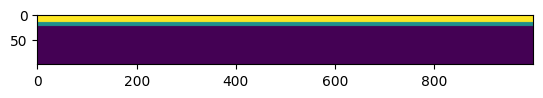

In [ ]:
plt.imshow(recon[800:900])
#plt.ylim(750, 850)

In [ ]:
# ══════════════════════════════════════════════════════════════
#  DEMO: synthetic 1000×1000 image
# ══════════════════════════════════════════════════════════════

if __name__ == "__main__":

    H, W = 1000, 1000

    print(f"Building synthetic {H}×{W} image ...")
    x = np.linspace(0, 8 * np.pi, W)
    y = np.linspace(0, 1, H)
    XX, YY = np.meshgrid(x, y)
    image = (np.sin(XX) * 0.5 + 0.5) * (1 - 0.3 * YY)
    image = image.astype(np.float32)

    # mask: two vertical gap bands
    mask = np.ones((H, W), dtype=bool)
    mask[:, 200:280] = False
    mask[:, 600:700] = False

    # ── run your chosen strategy ──
    # (A) patch-wise — good general purpose
    recon, uncert = gp_inpaint_patchwise(image, mask,
                                          patch_size=32,
                                          overlap=8,
                                          n_restarts=1)

    # (B) row-wise — uncomment to use instead
    # recon, uncert = gp_inpaint_rowwise(image, mask, n_restarts=1)

    # ── visualize a horizontal slice so we can actually see results ──
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].imshow(image,  cmap='gray', vmin=0, vmax=1)
    axes[0, 0].set_title("Original")

    masked_vis = image.copy()
    masked_vis[~mask] = 0.5
    axes[0, 1].imshow(masked_vis, cmap='gray', vmin=0, vmax=1)
    axes[0, 1].set_title("Masked input")

    axes[1, 0].imshow(recon,  cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title("GP reconstruction")

    im = axes[1, 1].imshow(uncert, cmap='hot')
    axes[1, 1].set_title("Uncertainty (std)")
    plt.colorbar(im, ax=axes[1, 1])

    for ax in axes.flat:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig("gp_large_inpaint.png", dpi=100)
    plt.show()
    print("Done → gp_large_inpaint.png")